# Object Detection

Object detection is a computer vision task that involves identifying and localizing objects within an image or video frame.

It's a fundamental problem in computer vision with various practical applications, including autonomous vehicles, surveillance systems, robotics, medical imaging, and more.

In [1]:
import sys
!{sys.executable} -m pip install "transformers<5.0" "huggingface-hub<1.0,>=0.34.0" "gradio<6" "numpy<2" --force-reinstall


  Using cached transformers-4.57.6-py3-none-any.whl.metadata (43 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached gradio-5.50.0-py3-none-any.whl.metadata (16 kB)
  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      + c:\Users\meet1\anaconda3\python.exe C:\Users\meet1\AppData\Local\Temp\pip-install-0ofaacmm\numpy_e2498055a5974716b26d5b4f193472bd\vendored-meson\meson\meson.py setup C:\Users\meet1\AppData\Local\Temp\pip-install-0ofaacmm\numpy_e2498055a5974716b26d5b4f193472bd C:\Users\meet1\AppData\Local\Temp\pip-install-0ofaacmm\numpy_e2498055a5974716b26d5b4f193472bd\.mesonpy-9wzg_7h9 -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\meet1\AppData\Local\Temp\pip-install-0ofaacmm\numpy_e2498055a5974716b26d5b4f193472bd\.mesonpy-9wzg_7h9\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.99
      Source dir: C:\Users\meet1\AppData\Local\Temp\pip-install-0ofaacmm\numpy_e2498055a5974716b26d5b4f193472bd
      Build dir: C:\Users\meet1\AppData\Local\Temp\pip-install-0ofaacmm\numpy_e2498055a5974716b2

In [2]:
# import libraries
from IPython.display import Image
Image(filename='image-2.png')

# Real life Example
from IPython.display import Image
Image(filename='Object_detection.png')

In [3]:
# To run this code on your own machine, you will need to install the following:

    # to load pre-trained models
#!pip install transformers

    # for creating web interfaces for machine learning models.
#!pip install gradio

    # PyTorch Image Models (timm), a collection of image models (CNN architectures) for PyTorch.
import sys
!{sys.executable} -m pip install timm

    # for generating plurals, singular nouns, ordinals, and indefinite articles.
import sys
!{sys.executable} -m pip install inflect

    # for converting text into phonetic (audio) transcriptions.
import sys
!{sys.executable} -m pip install phonemizer

# install the eSpeak software for TTS (text-to-speech) conversion
!sudo apt-get install python-espeak
!sudo apt-get update && sudo apt-get install espeak

Sudo is disabled on this machine. To enable it, go to the ]8;;ms-settings:developers\Developer Settings page]8;;\ in the Settings app
Sudo is disabled on this machine. To enable it, go to the ]8;;ms-settings:developers\Developer Settings page]8;;\ in the Settings app


### Build the `object-detection` pipeline using the transformers Library

- This model was release with the paper [End-to-End Object Detection with Transformers](https://arxiv.org/abs/2005.12872) from Carion et al. (2020)

In [4]:
# use the functions from the helper file
from helper import load_image_from_url, render_results_in_image

In [5]:
# import pipeline from transformers
from transformers import pipeline

In [6]:
# code to suppress warning messages
from transformers.utils import logging
logging.set_verbosity_error()

from helper import ignore_warnings
ignore_warnings()

In [7]:
# Import the model and create an instance
od_pipe = pipeline("object-detection", "facebook/detr-resnet-50")

c:\Users\meet1\anaconda3\Lib\site-packages\torch\nn\modules\module.py:2588: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
c:\Users\meet1\anaconda3\Lib\site-packages\torch\nn\modules\batchnorm.py:141: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
c:\Users\meet1\anaconda3\Lib\site-packages\torch\nn\modules\batchnorm.py:141: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current m

Info about [facebook/detr-resnet-50](https://huggingface.co/facebook/detr-resnet-50)

Explore more of the [Hugging Face Hub for more object detection models](https://huggingface.co/models?pipeline_tag=object-detection&sort=trending)

### Use the Pipeline

In [8]:
# Python Image Library
from PIL import Image

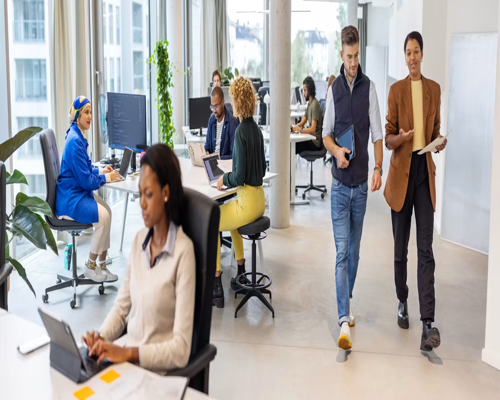

In [9]:
# Import the image
raw_image = Image.open('image-2.png')

# Resize as pre-processing step for standardized input size
raw_image.resize((500, 400))

In [10]:
# runt the model
pipeline_output = od_pipe(raw_image)

In [11]:
# valide the results
pipeline_output

[{'score': 0.9248427748680115,
  'label': 'potted plant',
  'box': {'xmin': 0, 'ymin': 284, 'xmax': 175, 'ymax': 523}},
 {'score': 0.9916879534721375,
  'label': 'laptop',
  'box': {'xmin': 114, 'ymin': 524, 'xmax': 331, 'ymax': 649}},
 {'score': 0.8104642629623413,
  'label': 'tv',
  'box': {'xmin': 562, 'ymin': 162, 'xmax': 675, 'ymax': 230}},
 {'score': 0.9807372689247131,
  'label': 'chair',
  'box': {'xmin': 102, 'ymin': 219, 'xmax': 326, 'ymax': 526}},
 {'score': 0.9985781908035278,
  'label': 'person',
  'box': {'xmin': 1146, 'ymin': 46, 'xmax': 1334, 'ymax': 596}},
 {'score': 0.8076028823852539,
  'label': 'tv',
  'box': {'xmin': 292, 'ymin': 156, 'xmax': 326, 'ymax': 255}},
 {'score': 0.9918920993804932,
  'label': 'chair',
  'box': {'xmin': 890, 'ymin': 200, 'xmax': 986, 'ymax': 343}},
 {'score': 0.9939775466918945,
  'label': 'person',
  'box': {'xmin': 633, 'ymin': 117, 'xmax': 666, 'ymax': 149}},
 {'score': 0.5169237852096558,
  'label': 'tv',
  'box': {'xmin': 0, 'ymin': 

- Return the results from the pipeline using the helper function `render_results_in_image`.

In [12]:
# render the image
processed_image = render_results_in_image(
    raw_image,
    pipeline_output)

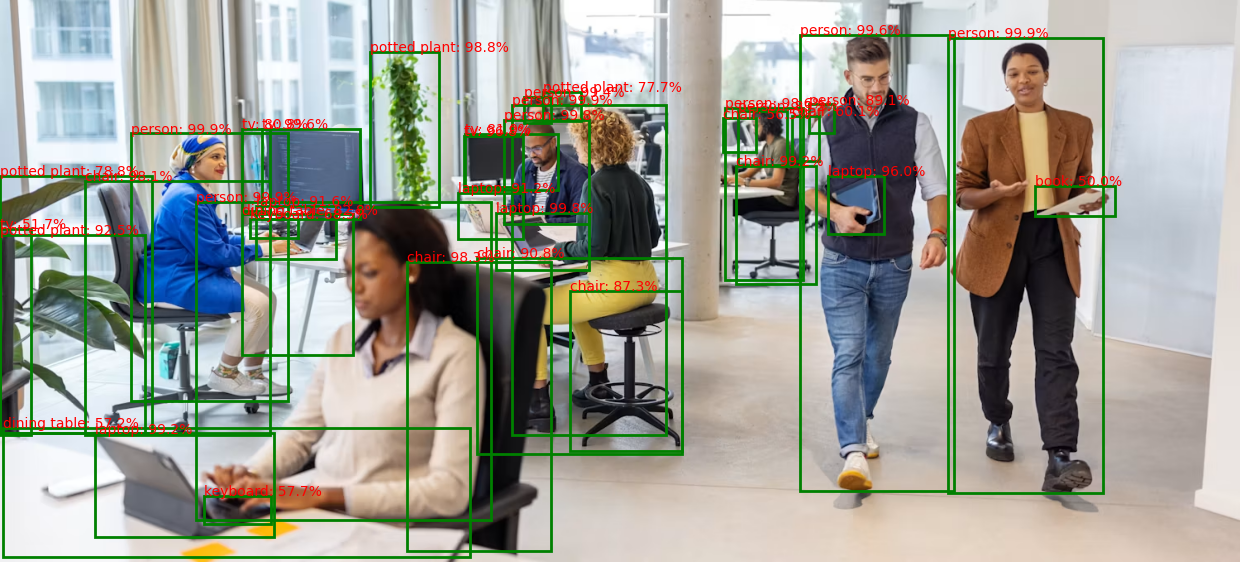

In [13]:
# view the final output
processed_image

### Using `Gradio` to create a Simple Interface

Gradio is a Python library that simplifies the process of creating web interfaces for machine learning models. It allows you to quickly build interactive web-based applications where users can interact with your machine learning models without needing to write any HTML, CSS, or JavaScript code.

Once you've imported Gradio, you can use its functions and classes to define input and output components, specify your machine learning model, and create a web interface that integrates with your model.

In [14]:
# import gradio
import gradio as gr

In [15]:
# this function will do all the steps under the hood

def get_pipeline_prediction(pil_image):

    # this will process the image and identify the objects
    pipeline_output = od_pipe(pil_image)

    # This will output the labelled image with boxes and confidence score
    processed_image = render_results_in_image(pil_image, pipeline_output)

    return processed_image

In [16]:
demo = gr.Interface(
  fn=get_pipeline_prediction,
  inputs=gr.Image(label="Input image",
                  type="pil"),
  outputs=gr.Image(label="Output image with predicted instances",
                   type="pil")
)

- `share=True` will provide an online link to access to the demo

In [17]:
# share=True will create a public link for sharing
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


### Close the app
- Remember to call `.close()` on the Gradio app when you're done using it.

In [18]:
# close when done
demo.close()

Closing server running on port: 7860


## Audio Assistant


- Combine the object detector with a text-to-speech model that will help dictate what is inside the image.


In [19]:
# Remember, our pipeline_output has the raw output from the object detection model
pipeline_output

[{'score': 0.9248427748680115,
  'label': 'potted plant',
  'box': {'xmin': 0, 'ymin': 284, 'xmax': 175, 'ymax': 523}},
 {'score': 0.9916879534721375,
  'label': 'laptop',
  'box': {'xmin': 114, 'ymin': 524, 'xmax': 331, 'ymax': 649}},
 {'score': 0.8104642629623413,
  'label': 'tv',
  'box': {'xmin': 562, 'ymin': 162, 'xmax': 675, 'ymax': 230}},
 {'score': 0.9807372689247131,
  'label': 'chair',
  'box': {'xmin': 102, 'ymin': 219, 'xmax': 326, 'ymax': 526}},
 {'score': 0.9985781908035278,
  'label': 'person',
  'box': {'xmin': 1146, 'ymin': 46, 'xmax': 1334, 'ymax': 596}},
 {'score': 0.8076028823852539,
  'label': 'tv',
  'box': {'xmin': 292, 'ymin': 156, 'xmax': 326, 'ymax': 255}},
 {'score': 0.9918920993804932,
  'label': 'chair',
  'box': {'xmin': 890, 'ymin': 200, 'xmax': 986, 'ymax': 343}},
 {'score': 0.9939775466918945,
  'label': 'person',
  'box': {'xmin': 633, 'ymin': 117, 'xmax': 666, 'ymax': 149}},
 {'score': 0.5169237852096558,
  'label': 'tv',
  'box': {'xmin': 0, 'ymin': 

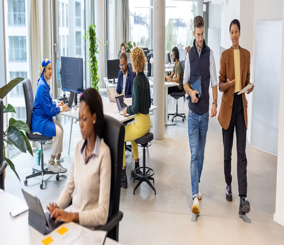

In [20]:
raw_image = Image.open('image-2.png')
raw_image.resize((284, 245))

In [21]:
# This will convert the raw output to a readable output
from helper import summarize_predictions_natural_language

text = summarize_predictions_natural_language(pipeline_output)
text

'In this image, there are four potted plants five laptops five tvs seven chairs ten persons two keyboards two dining tables and one book.'

## Generate Audio Narration of this Image

In [22]:
# Pipeline design
from IPython.display import Image
Image(filename='image-2.png')

In [23]:
# Text to Speech model
tts_pipe = pipeline("text-to-speech", model="kakao-enterprise/vits-ljs")

In [24]:
#from transformers import pipeline
tts_pipe = pipeline("text-to-audio", model="suno/bark-small")
tts_pipe

More info about [kakao-enterprise/vits-ljs](https://huggingface.co/kakao-enterprise/vits-ljs).

In [25]:
narrated_text = tts_pipe(text)

### Play the Generated Audio

In [26]:
from IPython.display import Audio as IPythonAudio

In [27]:
IPythonAudio(narrated_text["audio"][0],
             rate=narrated_text["sampling_rate"])

### Try it yourself!
- Try these models with other images!